# TinyGPT con Mixture of Experts (MoE)

**Autor: Carlos**

Este notebook implementa un modelo GPT con **Mixture of Experts (MoE)**, 
similar a arquitecturas de vanguardia como DeepSeek y Mistral.

## Objetivos
- Comprender en profundidad la implementación de un modelo GPT.
- Implementar una capa MoE para crear un modelo GPT de vanguardia.
- Explorar algoritmos de decodificación para generación de texto.

## 1. Importaciones y Configuración Inicial

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from dataclasses import dataclass, field
from typing import Optional, List, Type, Tuple
import httpx
import math

from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR

# Configuración del dispositivo
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## 2. Descarga y Preparación del Dataset

In [2]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = httpx.get(url)
text = response.text

text = text[:100_000]  # Usando 100k caracteres para mayor velocidad
print(f"Longitud del texto: {len(text)} caracteres")
print(f"Primeros 500 caracteres:\n{text[:500]}")

Longitud del texto: 100000 caracteres
Primeros 500 caracteres:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## 3. Tokenización basada en Caracteres

In [3]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Vocabulario: {vocab_size} caracteres únicos")
print(f"Caracteres: {''.join(chars)}")

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s: str) -> List[int]:
    """Convierte string a lista de índices."""
    return [stoi[c] for c in s]

def decode(l: List[int]) -> str:
    """Convierte lista de índices a string."""
    return ''.join([itos[i] for i in l])

# Codificar todo el texto
data = torch.tensor(encode(text), dtype=torch.long)

# División entrenamiento/validación (90/10)
split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

print(f"Datos de entrenamiento: {len(train_data)} tokens")
print(f"Datos de validación: {len(val_data)} tokens")

Vocabulario: 61 caracteres únicos
Caracteres: 
 !&',-.:;?ABCDEFGHIJKLMNOPQRSTUVWYabcdefghijklmnopqrstuvwxyz
Datos de entrenamiento: 90000 tokens
Datos de validación: 10000 tokens


## 4. Dataset y DataLoader

In [5]:
class CharDataset(Dataset):
    """Dataset para modelado de lenguaje a nivel de caracteres."""
    
    def __init__(self, data: torch.Tensor, block_size: int):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.block_size]
        y = self.data[idx + 1 : idx + self.block_size + 1]
        return x, y

## 5. Configuración del Modelo GPT con MoE

In [6]:
@dataclass
class MoEArgs:
    """
    Argumentos para la configuración de Mixture of Experts.
    
    Attributes:
        num_experts: Número total de expertos en la capa MoE.
        num_experts_per_token: Número de expertos activados por token (top-k routing).
        aux_loss_weight: Peso de la pérdida auxiliar para balanceo de carga.
    """
    num_experts: int = field(default=4)
    num_experts_per_token: int = field(default=2)
    aux_loss_weight: float = field(default=0.01)


@dataclass
class GPTConfig:
    """
    Configuración base para modelos GPT.
    
    Attributes:
        block_size: Longitud máxima de secuencia (contexto).
        batch_size: Tamaño del batch para entrenamiento.
        n_embd: Dimensión del embedding.
        n_head: Número de cabezas de atención.
        n_layer: Número de bloques transformer.
        dropout: Tasa de dropout.
        vocab_size: Tamaño del vocabulario.
        bias: Si usar bias en capas lineales.
        ff_class: Clase personalizada para FeedForward (permite MoE).
        moe: Configuración de Mixture of Experts.
    """
    block_size: int = 64
    batch_size: int = 32
    n_embd: int = 128
    n_head: int = 4
    n_layer: int = 4
    dropout: float = 0.1
    vocab_size: int = vocab_size
    bias: bool = True
    ff_class: Optional[Type[nn.Module]] = None
    moe: Optional[MoEArgs] = None

## 6. Componentes de Atención

In [7]:
class AttentionHead(nn.Module):
    """
    Cabeza de Atención Escalada (Scaled Dot-Product Attention).
    
    Implementa atención causal con soporte para KV-cache durante inferencia.
    """
    
    def __init__(self, args: GPTConfig) -> None:
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd debe ser divisible por n_head"
        self.head_dim = args.n_embd // args.n_head

        # Proyección QKV combinada para eficiencia
        self.key_query_value = nn.Linear(args.n_embd, 3 * self.head_dim, bias=args.bias)
        
        self.dropout = nn.Dropout(args.dropout)
        self.block_size = args.block_size
        
        # Máscara causal triangular inferior
        self.register_buffer('tril', torch.tril(torch.ones(args.block_size, args.block_size)))

    def forward(
        self, 
        x: torch.Tensor, 
        kv_cache: Optional[torch.Tensor] = None, 
        return_weights: bool = False
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        B, T, C = x.shape
        
        # Proyectar a Q, K, V
        key_query_value = self.key_query_value(x)
        k, q, v = torch.chunk(key_query_value, 3, dim=-1)

        # Concatenar con cache si existe
        if kv_cache is not None:
            key_cache, value_cache = kv_cache.unbind(dim=0)
            k = torch.cat((key_cache, k), dim=1)
            v = torch.cat((value_cache, v), dim=1)

        # Atención escalada
        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)
        
        # Aplicar máscara causal
        T_k = k.size(1)
        T_q = q.size(1)
        mask = self.tril[:T_q, :T_k]
        if kv_cache is not None:
            # Ajustar máscara para el caso con cache
            mask = torch.ones(T_q, T_k, device=x.device)
            mask = torch.tril(mask)
        wei = wei.masked_fill(mask == 0, float('-inf'))
        
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        out = wei @ v

        if return_weights:
            return out, wei

        if kv_cache is not None:
            return out, torch.stack((k, v))

        return out, None


class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention combinando múltiples cabezas de atención.
    """
    
    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd debe ser divisible por n_head"
        self.n_heads = args.n_head
        self.head_dim = args.n_embd // args.n_head

        self.heads = nn.ModuleList([
            AttentionHead(args) for _ in range(self.n_heads)
        ])

        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)
        self.dropout = nn.Dropout(args.dropout)

    def forward(
        self, 
        x: torch.Tensor, 
        kv_cache: Optional[List] = None, 
        return_weights: bool = False
    ):
        all_outputs = []
        all_weights = []
        new_kv_cache = [] if kv_cache is not None else None

        for i, head in enumerate(self.heads):
            head_cache = kv_cache[i] if kv_cache is not None else None
            out, weights_or_kv = head(x, kv_cache=head_cache, return_weights=return_weights)
            all_outputs.append(out)
            
            if return_weights:
                all_weights.append(weights_or_kv)
            if kv_cache is not None:
                new_kv_cache.append(weights_or_kv)

        concat = torch.cat(all_outputs, dim=-1)
        out = self.dropout(self.proj(concat))

        if return_weights:
            return out, torch.stack(all_weights)
        if kv_cache is not None:
            return out, new_kv_cache
        return out

## 7. FeedForward Estándar

In [8]:
class FeedForward(nn.Module):
    """
    Red FeedForward estándar con expansión 4x.
    """
    
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),  # GELU es más común en GPTs modernos
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

## 8. Mixture of Experts (MoE) - Implementación Completa

### Arquitectura MoE

La capa MoE consta de:
1. **Gate (Router)**: Determina qué expertos usar para cada token
2. **Experts**: Múltiples redes FFN independientes
3. **Combinación**: Pondera las salidas de los expertos seleccionados

Usamos **Top-K Routing** donde cada token activa solo K expertos.

In [9]:
class Expert(nn.Module):
    """
    Un experto MLP individual dentro de la capa MoE.
    
    Cada experto es una red feedforward independiente que se especializa
    en procesar ciertos tipos de tokens/patrones.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass del experto.
        
        Args:
            x: Tensor de entrada [batch, seq, n_embd] o [num_tokens, n_embd]
            
        Returns:
            Tensor procesado con las mismas dimensiones
        """
        return self.net(x)


class Gate(nn.Module):
    """
    Red de enrutamiento (Gating Network) para MoE.
    
    Calcula los pesos de cada experto para cada token usando softmax.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.proj = nn.Linear(config.n_embd, config.moe.num_experts)
        self.num_experts = config.moe.num_experts

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Calcula logits de routing para cada experto.
        
        Args:
            x: Tensor [batch, seq, n_embd]
            
        Returns:
            Logits de routing [batch, seq, num_experts]
        """
        return self.proj(x)


class MoELayer(nn.Module):
    """
    Capa Mixture of Experts con Top-K Routing.
    
    Esta implementación usa routing disperso (sparse routing) donde
    cada token solo activa un subconjunto de expertos (top-k).
    
    Características:
    - Top-K routing: Solo los K expertos con mayor score se activan
    - Load balancing loss: Pérdida auxiliar para distribución uniforme
    - Efficient batching: Los tokens se agrupan por experto para eficiencia
    """

    def __init__(
        self, 
        experts: List[nn.Module], 
        gate: nn.Module, 
        moe_args: MoEArgs
    ):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args
        self.num_experts = len(experts)
        self.num_experts_per_token = moe_args.num_experts_per_token
        self.aux_loss_weight = moe_args.aux_loss_weight
        
        # Para almacenar pérdida auxiliar durante forward
        self.aux_loss = 0.0

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass de la capa MoE.
        
        Implementa el algoritmo de routing top-k:
        1. Calcular scores del gate para todos los expertos
        2. Seleccionar top-k expertos por token
        3. Procesar cada token con sus expertos seleccionados
        4. Combinar salidas ponderadas
        
        Args:
            x: Tensor de entrada [batch, seq_len, n_embd]
            
        Returns:
            Tensor de salida [batch, seq_len, n_embd]
        """
        batch_size, seq_len, n_embd = x.shape
        
        # Aplanar batch y secuencia para procesar todos los tokens
        x_flat = x.view(-1, n_embd)  # [batch * seq_len, n_embd]
        num_tokens = x_flat.size(0)
        
        # Calcular scores del gate
        gate_logits = self.gate(x_flat)  # [num_tokens, num_experts]
        
        # Calcular pérdida auxiliar para balanceo de carga
        self.aux_loss = self._compute_load_balancing_loss(gate_logits)
        
        # Aplicar softmax para obtener probabilidades
        gate_probs = F.softmax(gate_logits, dim=-1)  # [num_tokens, num_experts]
        
        # Seleccionar top-k expertos
        top_k_probs, top_k_indices = torch.topk(
            gate_probs, 
            self.num_experts_per_token, 
            dim=-1
        )  # [num_tokens, k], [num_tokens, k]
        
        # Normalizar probabilidades de los expertos seleccionados
        top_k_probs = top_k_probs / top_k_probs.sum(dim=-1, keepdim=True)
        
        # Inicializar tensor de salida
        output = torch.zeros_like(x_flat)  # [num_tokens, n_embd]
        
        # Procesar cada experto
        for expert_idx in range(self.num_experts):
            expert = self.experts[expert_idx]
            
            # Encontrar qué tokens usan este experto y en qué posición (0 a k-1)
            # mask: [num_tokens, k] - True donde top_k_indices == expert_idx
            mask = (top_k_indices == expert_idx)
            
            # Obtener índices de tokens que usan este experto
            token_indices = mask.any(dim=-1).nonzero(as_tuple=True)[0]
            
            if len(token_indices) == 0:
                continue
            
            # Obtener tokens para este experto
            expert_input = x_flat[token_indices]  # [num_selected, n_embd]
            
            # Procesar con el experto
            expert_output = expert(expert_input)  # [num_selected, n_embd]
            
            # Obtener los pesos correspondientes
            # Para cada token seleccionado, encontrar el peso del experto actual
            weights_mask = mask[token_indices]  # [num_selected, k]
            probs_selected = top_k_probs[token_indices]  # [num_selected, k]
            
            # Obtener el peso para este experto (donde mask es True)
            expert_weights = (probs_selected * weights_mask.float()).sum(dim=-1, keepdim=True)
            
            # Acumular salida ponderada
            output[token_indices] += expert_weights * expert_output
        
        # Restaurar forma original
        output = output.view(batch_size, seq_len, n_embd)
        
        return output

    def _compute_load_balancing_loss(self, gate_logits: torch.Tensor) -> torch.Tensor:
        """
        Calcula la pérdida de balanceo de carga para distribución uniforme.
        
        Esto incentiva que todos los expertos reciban aproximadamente
        el mismo número de tokens, evitando el colapso donde un solo
        experto procesa todo.
        
        Args:
            gate_logits: Logits del gate [num_tokens, num_experts]
            
        Returns:
            Pérdida escalar de balanceo
        """
        num_tokens = gate_logits.size(0)
        
        # Probabilidades de routing
        probs = F.softmax(gate_logits, dim=-1)  # [num_tokens, num_experts]
        
        # Fracción de tokens asignados a cada experto (promedio)
        # Representa cuánto "peso" total recibe cada experto
        tokens_per_expert = probs.mean(dim=0)  # [num_experts]
        
        # Probabilidad promedio de elegir cada experto
        # Usando la selección hard (argmax)
        expert_selection = torch.argmax(gate_logits, dim=-1)  # [num_tokens]
        expert_counts = torch.zeros(self.num_experts, device=gate_logits.device)
        for i in range(self.num_experts):
            expert_counts[i] = (expert_selection == i).float().sum()
        expert_fraction = expert_counts / num_tokens  # [num_experts]
        
        # Pérdida: producto de las dos distribuciones
        # Minimizar esto fomenta distribución uniforme
        aux_loss = (tokens_per_expert * expert_fraction).sum() * self.num_experts
        
        return aux_loss * self.aux_loss_weight


class MoEFFN(nn.Module):
    """
    Wrapper de MoE para usar como reemplazo de FeedForward en GPT.
    
    Esta clase envuelve MoELayer para que sea compatible con la interfaz
    esperada por el Block de GPT.
    """
    
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.moe = MoELayer(
            experts=[Expert(config) for _ in range(config.moe.num_experts)],
            gate=Gate(config),
            moe_args=config.moe
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.moe(x)
    
    def get_aux_loss(self) -> torch.Tensor:
        """Retorna la pérdida auxiliar de balanceo."""
        return self.moe.aux_loss

## 9. Bloque Transformer

In [10]:
class Block(nn.Module):
    """
    Bloque Transformer con atención y feedforward (o MoE).
    
    Arquitectura Pre-LN (LayerNorm antes de cada sublayer):
    x -> LN -> Attention -> + -> LN -> FFN/MoE -> +
    |________________________|    |_______________|
    """
    
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        # Usar MoE si está configurado, sino FeedForward estándar
        ff_class = config.ff_class if config.ff_class is not None else FeedForward
        self.ff = ff_class(config)
        
        self.is_moe = config.ff_class is not None and config.moe is not None

    def forward(
        self, 
        x: torch.Tensor, 
        kv_cache: Optional[List] = None, 
        return_weights: bool = False
    ):
        # Self-attention con conexión residual
        attn_out = self.attn(self.ln1(x), kv_cache=kv_cache, return_weights=return_weights)
        
        if return_weights:
            attn_out, weights = attn_out
        else:
            weights = None

        if isinstance(attn_out, tuple):
            attn_out, updated_kv = attn_out
        else:
            updated_kv = None

        x = x + attn_out
        
        # FeedForward/MoE con conexión residual
        x = x + self.ff(self.ln2(x))
        
        return (x, updated_kv, weights) if return_weights else (x, updated_kv)
    
    def get_aux_loss(self) -> torch.Tensor:
        """Retorna pérdida auxiliar si usa MoE."""
        if self.is_moe and hasattr(self.ff, 'get_aux_loss'):
            return self.ff.get_aux_loss()
        return 0.0

## 10. Arquitectura TinyGPT con MoE

In [11]:
class TinyGPT(nn.Module):
    """
    TinyGPT: Un modelo GPT pequeño con soporte opcional para MoE.
    
    Arquitectura:
    - Token Embeddings + Positional Embeddings
    - N bloques Transformer (cada uno con Attention + FFN/MoE)
    - LayerNorm final
    - Head de proyección al vocabulario
    """
    
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.config = config
        
        # Weight tying: compartir pesos entre embedding y head
        self.head.weight = self.token_emb.weight
        
        # Inicialización de pesos
        self.apply(self._init_weights)
        
        # Contar parámetros
        n_params = sum(p.numel() for p in self.parameters())
        print(f"Número de parámetros: {n_params/1e6:.2f}M")

    def _init_weights(self, module):
        """Inicialización de pesos estilo GPT-2."""
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            torch.nn.init.zeros_(module.bias)
            torch.nn.init.ones_(module.weight)

    def forward(
        self, 
        idx: torch.Tensor, 
        kv_cache: Optional[List] = None, 
        return_weights: bool = False
    ):
        B, T = idx.shape
        
        # Embeddings
        tok_emb = self.token_emb(idx)
        
        # Posiciones (ajustadas para KV-cache)
        if kv_cache is not None and len(kv_cache) > 0 and kv_cache[0] is not None:
            # Obtener longitud del cache
            cache_len = kv_cache[0][0].size(1) if kv_cache[0] is not None else 0
            pos = torch.arange(cache_len, cache_len + T, device=idx.device)
        else:
            pos = torch.arange(T, device=idx.device)
        pos_emb = self.pos_emb(pos)[None, :, :]
        
        x = tok_emb + pos_emb

        new_kv_cache = [] if kv_cache is not None else None
        all_weights = [] if return_weights else None
        aux_loss = 0.0

        for i, block in enumerate(self.blocks):
            layer_kv = kv_cache[i] if kv_cache is not None else None
            
            if return_weights:
                x, updated_kv, weights = block(x, kv_cache=layer_kv, return_weights=True)
                all_weights.append(weights)
            else:
                x, updated_kv = block(x, kv_cache=layer_kv)
            
            if kv_cache is not None:
                new_kv_cache.append(updated_kv)
            
            # Acumular pérdida auxiliar de MoE
            aux_loss += block.get_aux_loss()

        x = self.ln_f(x)
        logits = self.head(x)

        # Almacenar pérdida auxiliar para acceso externo
        self.aux_loss = aux_loss

        if return_weights:
            if kv_cache is not None:
                return logits, new_kv_cache, all_weights
            else:
                return logits, all_weights
        else:
            if kv_cache is not None:
                return logits, new_kv_cache
            return logits
    
    def get_aux_loss(self) -> torch.Tensor:
        """Retorna la pérdida auxiliar acumulada de MoE."""
        return getattr(self, 'aux_loss', 0.0)

## 11. Funciones de Generación

Implementamos múltiples estrategias de decodificación:
- **Greedy**: Selecciona el token más probable
- **Temperature**: Ajusta la "creatividad" de la distribución
- **Top-K**: Muestrea solo de los K tokens más probables
- **Top-P (Nucleus)**: Muestrea del conjunto mínimo que suma probabilidad P

In [12]:
@torch.no_grad()
def generate(
    model: nn.Module,
    prompt: str, 
    max_new_tokens: int = 100, 
    use_cache: bool = True
) -> str:
    """
    Generación básica con muestreo de la distribución completa.
    
    Args:
        model: Modelo TinyGPT
        prompt: Texto inicial
        max_new_tokens: Número máximo de tokens a generar
        use_cache: Si usar KV-cache para eficiencia
        
    Returns:
        Texto generado
    """
    model.eval()
    config = model.config
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None

        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())


@torch.no_grad()
def generate_v2(
    model: nn.Module,
    prompt: str,
    max_new_tokens: int = 100,
    use_cache: bool = True,
    temperature: float = 1.0,
    top_k: Optional[int] = None,
    top_p: Optional[float] = None,
    do_sample: bool = True,
) -> str:
    """
    Generación avanzada con múltiples estrategias de decodificación.
    
    Args:
        model: Modelo TinyGPT
        prompt: Texto inicial
        max_new_tokens: Número máximo de tokens a generar
        use_cache: Si usar KV-cache
        temperature: Factor de temperatura (< 1 = más determinista, > 1 = más aleatorio)
        top_k: Si se especifica, solo muestrea de los k tokens más probables
        top_p: Si se especifica, usa nucleus sampling (probabilidad acumulada)
        do_sample: Si False, usa decodificación greedy
        
    Returns:
        Texto generado
    """
    model.eval()
    config = model.config
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        # Preparar entrada (con o sin cache)
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        # Forward pass
        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None

        # Obtener logits del último token
        logits = logits[:, -1, :]  # [batch, vocab]
        
        # === DECODIFICACIÓN GREEDY ===
        if not do_sample:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
            idx = torch.cat((idx, next_token), dim=1)
            continue
        
        # === APLICAR TEMPERATURA ===
        if temperature != 1.0:
            logits = logits / temperature
        
        # === TOP-K FILTERING ===
        if top_k is not None and top_k > 0:
            # Mantener solo los top_k logits más altos
            top_k_val = min(top_k, logits.size(-1))
            indices_to_remove = logits < torch.topk(logits, top_k_val)[0][..., -1, None]
            logits[indices_to_remove] = float('-inf')
        
        # === TOP-P (NUCLEUS) FILTERING ===
        if top_p is not None and 0.0 < top_p < 1.0:
            # Ordenar logits de mayor a menor
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            sorted_probs = F.softmax(sorted_logits, dim=-1)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
            
            # Encontrar dónde la probabilidad acumulada supera top_p
            sorted_indices_to_remove = cumulative_probs > top_p
            # Shift para mantener el primer token que supera el umbral
            sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
            sorted_indices_to_remove[..., 0] = False
            
            # Restaurar orden original y aplicar máscara
            indices_to_remove = sorted_indices_to_remove.scatter(
                dim=-1, index=sorted_indices, src=sorted_indices_to_remove
            )
            logits[indices_to_remove] = float('-inf')
        
        # Convertir a probabilidades y muestrear
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        
        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())


def greedy_decode(model: nn.Module, prompt: str, max_new_tokens: int = 100) -> str:
    """Decodificación greedy: siempre selecciona el token más probable."""
    return generate_v2(model, prompt, max_new_tokens, do_sample=False)


def temperature_sampling(
    model: nn.Module, 
    prompt: str, 
    max_new_tokens: int = 100, 
    temperature: float = 0.7
) -> str:
    """Muestreo con temperatura ajustada."""
    return generate_v2(model, prompt, max_new_tokens, temperature=temperature)


def top_k_sampling(
    model: nn.Module, 
    prompt: str, 
    max_new_tokens: int = 100, 
    k: int = 50
) -> str:
    """Muestreo top-k."""
    return generate_v2(model, prompt, max_new_tokens, top_k=k)


def nucleus_sampling(
    model: nn.Module, 
    prompt: str, 
    max_new_tokens: int = 100, 
    p: float = 0.9
) -> str:
    """Muestreo nucleus (top-p)."""
    return generate_v2(model, prompt, max_new_tokens, top_p=p)

## 12. Trainer

In [15]:
class Trainer:
    """
    Clase de entrenamiento para TinyGPT con soporte para MoE.
    
    Características:
    - Mixed precision training (AMP)
    - Gradient accumulation
    - Checkpointing
    - Pérdida auxiliar de MoE
    """
    
    def __init__(
        self,
        model: nn.Module,
        train_data_loader: DataLoader,
        test_data_loader: DataLoader,
        loss_fn: nn.Module,
        optimizer: torch.optim.Optimizer,
        scheduler: Optional[torch.optim.lr_scheduler._LRScheduler] = None,
        device: str = 'cpu',
        gradient_accumulation_steps: int = 1,
        save_dir: str = "./checkpoints",
        save_every_n: int = 500,
    ):
        self.model = model
        self.train_loader = train_data_loader
        self.test_loader = test_data_loader
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.grad_accum_steps = gradient_accumulation_steps
        self.save_dir = save_dir
        self.save_every_n = save_every_n
        self.global_step = 0
        
    def train_model_v2(
        self, 
        use_amp: bool = False, 
        dtype: torch.dtype = torch.float16
    ) -> float:
        """
        Entrena el modelo por una época.
        
        Args:
            use_amp: Si usar mixed precision
            dtype: Tipo de datos para AMP
            
        Returns:
            Pérdida promedio de la época
        """
        self.model.train()
        total_loss = 0.0
        num_batches = 0
        
        scaler = torch.amp.GradScaler(device=self.device) if use_amp else None
        
        for batch_idx, (x, y) in enumerate(self.train_loader):
            x, y = x.to(self.device), y.to(self.device)
            
            if use_amp:
                with torch.amp.autocast(device_type=self.device, dtype=dtype):
                    logits = self.model(x)
                    if isinstance(logits, tuple):
                        logits = logits[0]
                    
                    # Calcular pérdida principal
                    loss = self.loss_fn(
                        logits.view(-1, logits.size(-1)), 
                        y.view(-1)
                    )
                    
                    # Añadir pérdida auxiliar de MoE
                    if hasattr(self.model, 'get_aux_loss'):
                        aux_loss = self.model.get_aux_loss()
                        if isinstance(aux_loss, torch.Tensor):
                            loss = loss + aux_loss
                    
                    loss = loss / self.grad_accum_steps
                
                scaler.scale(loss).backward()
                
                if (batch_idx + 1) % self.grad_accum_steps == 0:
                    scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    scaler.step(self.optimizer)
                    scaler.update()
                    self.optimizer.zero_grad()
                    
                    if self.scheduler is not None:
                        self.scheduler.step()
            else:
                logits = self.model(x)
                if isinstance(logits, tuple):
                    logits = logits[0]
                
                loss = self.loss_fn(
                    logits.view(-1, logits.size(-1)), 
                    y.view(-1)
                )
                
                if hasattr(self.model, 'get_aux_loss'):
                    aux_loss = self.model.get_aux_loss()
                    if isinstance(aux_loss, torch.Tensor):
                        loss = loss + aux_loss
                
                loss = loss / self.grad_accum_steps
                loss.backward()
                
                if (batch_idx + 1) % self.grad_accum_steps == 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.optimizer.step()
                    self.optimizer.zero_grad()
                    
                    if self.scheduler is not None:
                        self.scheduler.step()
            
            total_loss += loss.item() * self.grad_accum_steps
            num_batches += 1
            self.global_step += 1
            
            if batch_idx % 100 == 0:
                print(f"  Batch {batch_idx}/{len(self.train_loader)}, Loss: {loss.item() * self.grad_accum_steps:.4f}")
        
        return total_loss / num_batches
    
    @torch.no_grad()
    def eval_model(self) -> float:
        """Evalúa el modelo en el conjunto de validación."""
        self.model.eval()
        total_loss = 0.0
        num_batches = 0
        
        for x, y in self.test_loader:
            x, y = x.to(self.device), y.to(self.device)
            
            logits = self.model(x)
            if isinstance(logits, tuple):
                logits = logits[0]
            
            loss = self.loss_fn(
                logits.view(-1, logits.size(-1)), 
                y.view(-1)
            )
            
            total_loss += loss.item()
            num_batches += 1
        
        return total_loss / num_batches

## 13. Visualización de Atención

In [16]:
@torch.no_grad()
def visualize_attention(model: nn.Module, prompt: str, max_len: int = 10):
    """
    Visualiza los mapas de atención del modelo.
    
    Args:
        model: Modelo TinyGPT
        prompt: Texto de entrada
        max_len: No usado, mantenido por compatibilidad
    """
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)

    # Forward con return_weights=True
    logits, all_weights = model(idx, return_weights=True)

    n_layers = len(all_weights)
    n_heads = all_weights[0].shape[0]
    seq_len = all_weights[0].shape[-1]
    
    tokens = list(prompt)

    for layer_i in range(n_layers):
        fig, axes = plt.subplots(1, n_heads, figsize=(5 * n_heads, 5))
        if n_heads == 1:
            axes = [axes]
        
        for head_i in range(n_heads):
            attn = all_weights[layer_i][head_i, 0].cpu()
            im = axes[head_i].imshow(attn, cmap='viridis')
            axes[head_i].set_title(f'Capa {layer_i + 1}, Cabeza {head_i + 1}')
            axes[head_i].set_xlabel('Posición Key')
            axes[head_i].set_ylabel('Posición Query')
            
            # Añadir etiquetas de tokens si caben
            if seq_len <= 20:
                axes[head_i].set_xticks(range(seq_len))
                axes[head_i].set_yticks(range(seq_len))
                axes[head_i].set_xticklabels(tokens[:seq_len], rotation=45)
                axes[head_i].set_yticklabels(tokens[:seq_len])
            
            fig.colorbar(im, ax=axes[head_i])
        
        plt.tight_layout()
        plt.savefig(f'attention_layer_{layer_i+1}.png', dpi=150, bbox_inches='tight')
        plt.show()

## 14. Entrenamiento del Modelo Base (sin MoE)

In [17]:
print("="*60)
print("ENTRENAMIENTO DE TINYGPT BASE (sin MoE)")
print("="*60)

# Configuración base
config_base = GPTConfig(
    block_size=64,
    batch_size=32,
    n_embd=128,
    n_head=4,
    n_layer=4,
    dropout=0.1,
    vocab_size=vocab_size,
)

# Datasets
train_dataset = CharDataset(train_data, config_base.block_size)
val_dataset = CharDataset(val_data, config_base.block_size)

train_loader = DataLoader(
    train_dataset,
    batch_size=config_base.batch_size,
    shuffle=True,
    drop_last=True,
    pin_memory=True,
    num_workers=0,  # Usar 0 para compatibilidad
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config_base.batch_size,
    shuffle=False,
    drop_last=True,
    pin_memory=True,
    num_workers=0,
)

# Modelo base
model_base = TinyGPT(config_base).to(device)

# Intentar compilar (solo funciona en PyTorch 2.0+)
try:
    model_base = torch.compile(model_base)
    print("Modelo compilado con torch.compile()")
except Exception as e:
    print(f"torch.compile() no disponible: {e}")

optimizer_base = AdamW(model_base.parameters(), lr=1e-3)
scheduler_base = StepLR(optimizer_base, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()

trainer_base = Trainer(
    model=model_base,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer_base,
    scheduler=scheduler_base,
    device=device,
)

epochs = 2
print(f"\nEntrenando por {epochs} épocas...")

for epoch in range(epochs):
    print(f"\n--- Época {epoch + 1}/{epochs} ---")
    avg_train_loss = trainer_base.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Pérdida de entrenamiento: {avg_train_loss:.4f}")
    
    val_loss = trainer_base.eval_model()
    print(f"Pérdida de validación: {val_loss:.4f}")

print("\nEntrenamiento del modelo base completo.")

ENTRENAMIENTO DE TINYGPT BASE (sin MoE)
Número de parámetros: 0.81M
Modelo compilado con torch.compile()

Entrenando por 2 épocas...

--- Época 1/2 ---


W0414 02:39:46.670000 55 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


  Batch 0/2810, Loss: 4.1435
  Batch 100/2810, Loss: 2.4003
  Batch 200/2810, Loss: 2.3144
  Batch 300/2810, Loss: 2.0738
  Batch 400/2810, Loss: 1.9921
  Batch 500/2810, Loss: 1.9265
  Batch 600/2810, Loss: 1.8158
  Batch 700/2810, Loss: 1.8320
  Batch 800/2810, Loss: 1.7647
  Batch 900/2810, Loss: 1.6724
  Batch 1000/2810, Loss: 1.6409
  Batch 1100/2810, Loss: 1.5922
  Batch 1200/2810, Loss: 1.6180
  Batch 1300/2810, Loss: 1.5492
  Batch 1400/2810, Loss: 1.6506
  Batch 1500/2810, Loss: 1.6334
  Batch 1600/2810, Loss: 1.5704
  Batch 1700/2810, Loss: 1.5378
  Batch 1800/2810, Loss: 1.4532
  Batch 1900/2810, Loss: 1.5841
  Batch 2000/2810, Loss: 1.5711
  Batch 2100/2810, Loss: 1.4107
  Batch 2200/2810, Loss: 1.5847
  Batch 2300/2810, Loss: 1.5100
  Batch 2400/2810, Loss: 1.5642
  Batch 2500/2810, Loss: 1.4649
  Batch 2600/2810, Loss: 1.4621
  Batch 2700/2810, Loss: 1.4840
  Batch 2800/2810, Loss: 1.5052
Pérdida de entrenamiento: 1.7118
Pérdida de validación: 1.5487

--- Época 2/2 ---
  

## 15. Pruebas de Generación (Modelo Base)

In [18]:
print("\n" + "="*60)
print("PRUEBAS DE GENERACIÓN - MODELO BASE")
print("="*60)

prompt = "To be or not to be"
print(f"\nPrompt: '{prompt}'\n")

print("--- Muestreo básico ---")
print(generate(model_base, prompt, max_new_tokens=100))

print("\n--- Decodificación Greedy ---")
print(greedy_decode(model_base, prompt, max_new_tokens=100))

print("\n--- Temperature = 0.5 (más determinista) ---")
print(temperature_sampling(model_base, prompt, max_new_tokens=100, temperature=0.5))

print("\n--- Temperature = 1.5 (más creativo) ---")
print(temperature_sampling(model_base, prompt, max_new_tokens=100, temperature=1.5))

print("\n--- Top-K = 10 ---")
print(top_k_sampling(model_base, prompt, max_new_tokens=100, k=10))

print("\n--- Nucleus (Top-P = 0.9) ---")
print(nucleus_sampling(model_base, prompt, max_new_tokens=100, p=0.9))


PRUEBAS DE GENERACIÓN - MODELO BASE

Prompt: 'To be or not to be'

--- Muestreo básico ---
To be or not to beajeftn?
He's general you, their parts. Which is bear the raves duers,
Which 's he fall and them's th

--- Decodificación Greedy ---
To be or not to be the common the world
Than the people the people the people, the people,
And the state of the people

--- Temperature = 0.5 (más determinista) ---
To be or not to be the were the people,
When would do better a please you.

SICINIUS:
Well, no, the say are to the con

--- Temperature = 1.5 (más creativo) ---
To be or not to be.

First  &F:
Nowll not thwiles gent.

CORIOLANUS:
A we theme we grues, Mick's:
Beans.
Here spet'; b

--- Top-K = 10 ---
To be or not to be you.

VOLUMNIA:
Indeed, and madam; who done honours now bear your almy.

First Citizen:
Would you s

--- Nucleus (Top-P = 0.9) ---
To be or not to be the what be heard and o' the now worsh me
Do it the before to man your cower down: with all faway a


## 16. Entrenamiento de TinyGPT con MoE

In [19]:
print("\n" + "="*60)
print("ENTRENAMIENTO DE TINYGPT CON MIXTURE OF EXPERTS (MoE)")
print("="*60)

# Configuración con MoE
moe_args = MoEArgs(
    num_experts=4,          # 4 expertos
    num_experts_per_token=2,  # Cada token usa 2 expertos
    aux_loss_weight=0.01    # Peso de la pérdida de balanceo
)

config_moe = GPTConfig(
    block_size=64,
    batch_size=32,
    n_embd=128,
    n_head=4,
    n_layer=4,
    dropout=0.1,
    vocab_size=vocab_size,
    ff_class=MoEFFN,  # Usar MoE en lugar de FeedForward
    moe=moe_args,
)

# Modelo MoE
model_moe = TinyGPT(config_moe).to(device)

try:
    model_moe = torch.compile(model_moe)
    print("Modelo MoE compilado con torch.compile()")
except Exception as e:
    print(f"torch.compile() no disponible: {e}")

optimizer_moe = AdamW(model_moe.parameters(), lr=1e-3)
scheduler_moe = StepLR(optimizer_moe, step_size=100, gamma=0.9)

trainer_moe = Trainer(
    model=model_moe,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer_moe,
    scheduler=scheduler_moe,
    device=device,
)

print(f"\nEntrenando modelo MoE por {epochs} épocas...")

for epoch in range(epochs):
    print(f"\n--- Época {epoch + 1}/{epochs} ---")
    avg_train_loss = trainer_moe.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Pérdida de entrenamiento: {avg_train_loss:.4f}")
    
    val_loss = trainer_moe.eval_model()
    print(f"Pérdida de validación: {val_loss:.4f}")

print("\nEntrenamiento del modelo MoE completo.")


ENTRENAMIENTO DE TINYGPT CON MIXTURE OF EXPERTS (MoE)
Número de parámetros: 2.39M
Modelo MoE compilado con torch.compile()

Entrenando modelo MoE por 2 épocas...

--- Época 1/2 ---


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


  Batch 0/2810, Loss: 4.1852
  Batch 100/2810, Loss: 2.4331
  Batch 200/2810, Loss: 2.3177
  Batch 300/2810, Loss: 2.1351
  Batch 400/2810, Loss: 1.9760
  Batch 500/2810, Loss: 1.9006
  Batch 600/2810, Loss: 1.7453
  Batch 700/2810, Loss: 1.8123
  Batch 800/2810, Loss: 1.6033
  Batch 900/2810, Loss: 1.6762
  Batch 1000/2810, Loss: 1.5920
  Batch 1100/2810, Loss: 1.6053
  Batch 1200/2810, Loss: 1.5912
  Batch 1300/2810, Loss: 1.6698
  Batch 1400/2810, Loss: 1.5226
  Batch 1500/2810, Loss: 1.5090
  Batch 1600/2810, Loss: 1.4591
  Batch 1700/2810, Loss: 1.4856
  Batch 1800/2810, Loss: 1.4776
  Batch 1900/2810, Loss: 1.4053
  Batch 2000/2810, Loss: 1.4506
  Batch 2100/2810, Loss: 1.4297
  Batch 2200/2810, Loss: 1.4082
  Batch 2300/2810, Loss: 1.3627
  Batch 2400/2810, Loss: 1.3454
  Batch 2500/2810, Loss: 1.4037
  Batch 2600/2810, Loss: 1.3262
  Batch 2700/2810, Loss: 1.3341
  Batch 2800/2810, Loss: 1.3488
Pérdida de entrenamiento: 1.6396
Pérdida de validación: 1.5238

--- Época 2/2 ---
  

## 17. Pruebas de Generación (Modelo MoE)

In [20]:
print("\n" + "="*60)
print("PRUEBAS DE GENERACIÓN - MODELO MoE")
print("="*60)

prompt = "To be or not to be"
print(f"\nPrompt: '{prompt}'\n")

print("--- Muestreo básico ---")
print(generate(model_moe, prompt, max_new_tokens=100))

print("\n--- Decodificación Greedy ---")
print(greedy_decode(model_moe, prompt, max_new_tokens=100))

print("\n--- Temperature = 0.7 + Top-K = 50 ---")
print(generate_v2(model_moe, prompt, max_new_tokens=100, temperature=0.7, top_k=50))

print("\n--- Temperature = 0.9 + Nucleus (Top-P = 0.95) ---")
print(generate_v2(model_moe, prompt, max_new_tokens=100, temperature=0.9, top_p=0.95))


PRUEBAS DE GENERACIÓN - MODELO MoE

Prompt: 'To be or not to be'

--- Muestreo básico ---
To be or not to better with me? Geet you talk
Be they shut you, persoy not too the mutinutes?
If would Marcius promped

--- Decodificación Greedy ---
To be or not to be to the people,
And the common the people, when you shall be consul,
Which the should be strong them

--- Temperature = 0.7 + Top-K = 50 ---
To be or not to be to be common to the people;
Where that he had your friends intry, and do see
Upor the publys as the

--- Temperature = 0.9 + Nucleus (Top-P = 0.95) ---
To be or not to bear the such o' the world: he had on thought
In wash your sound.

VIRGILIA:
That would made but less,


## 18. Comparación de Modelos

In [21]:
print("\n" + "="*60)
print("COMPARACIÓN: MODELO BASE vs MoE")
print("="*60)

def count_parameters(model):
    """Cuenta parámetros totales y entrenables."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_base, train_base = count_parameters(model_base)
total_moe, train_moe = count_parameters(model_moe)

print(f"\nModelo Base:")
print(f"  - Parámetros totales: {total_base:,}")
print(f"  - Parámetros entrenables: {train_base:,}")

print(f"\nModelo MoE ({moe_args.num_experts} expertos, {moe_args.num_experts_per_token} activos por token):")
print(f"  - Parámetros totales: {total_moe:,}")
print(f"  - Parámetros entrenables: {train_moe:,}")
print(f"  - Incremento: {(total_moe - total_base) / total_base * 100:.1f}%")

print(f"\nNota: MoE tiene más parámetros pero solo activa {moe_args.num_experts_per_token}/{moe_args.num_experts}")
print(f"expertos por token, manteniendo el costo computacional similar al modelo base.")


COMPARACIÓN: MODELO BASE vs MoE

Modelo Base:
  - Parámetros totales: 809,344
  - Parámetros entrenables: 809,344

Modelo MoE (4 expertos, 2 activos por token):
  - Parámetros totales: 2,391,952
  - Parámetros entrenables: 2,391,952
  - Incremento: 195.5%

Nota: MoE tiene más parámetros pero solo activa 2/4
expertos por token, manteniendo el costo computacional similar al modelo base.


## 19. Visualización de Atención


VISUALIZACIÓN DE ATENCIÓN

Visualizando atención para: 'To be or not'


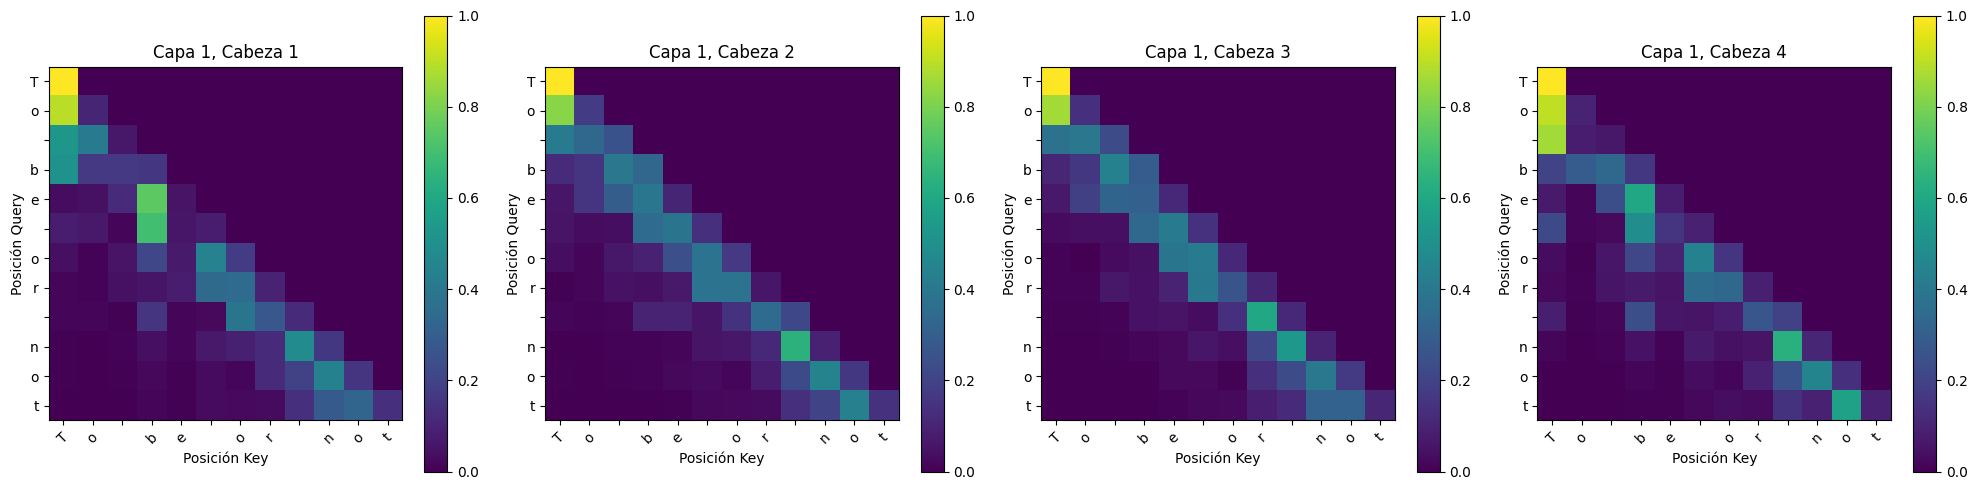

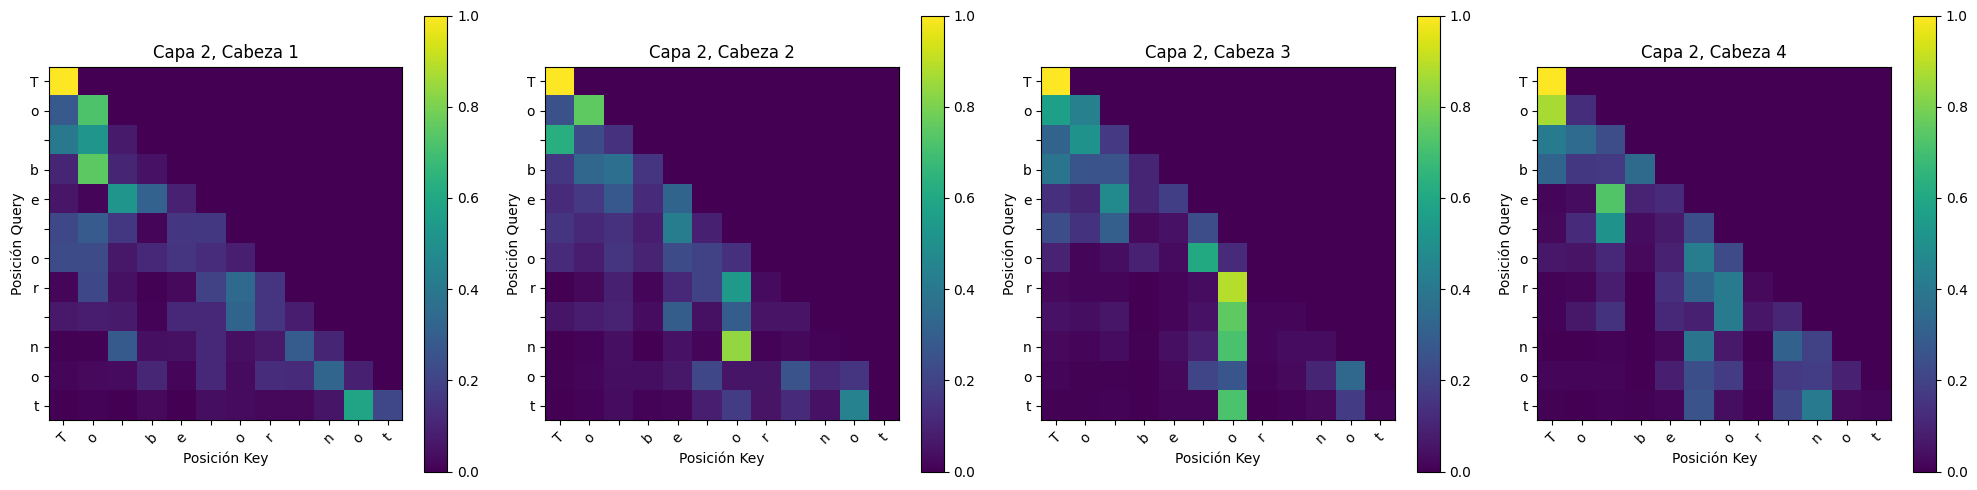

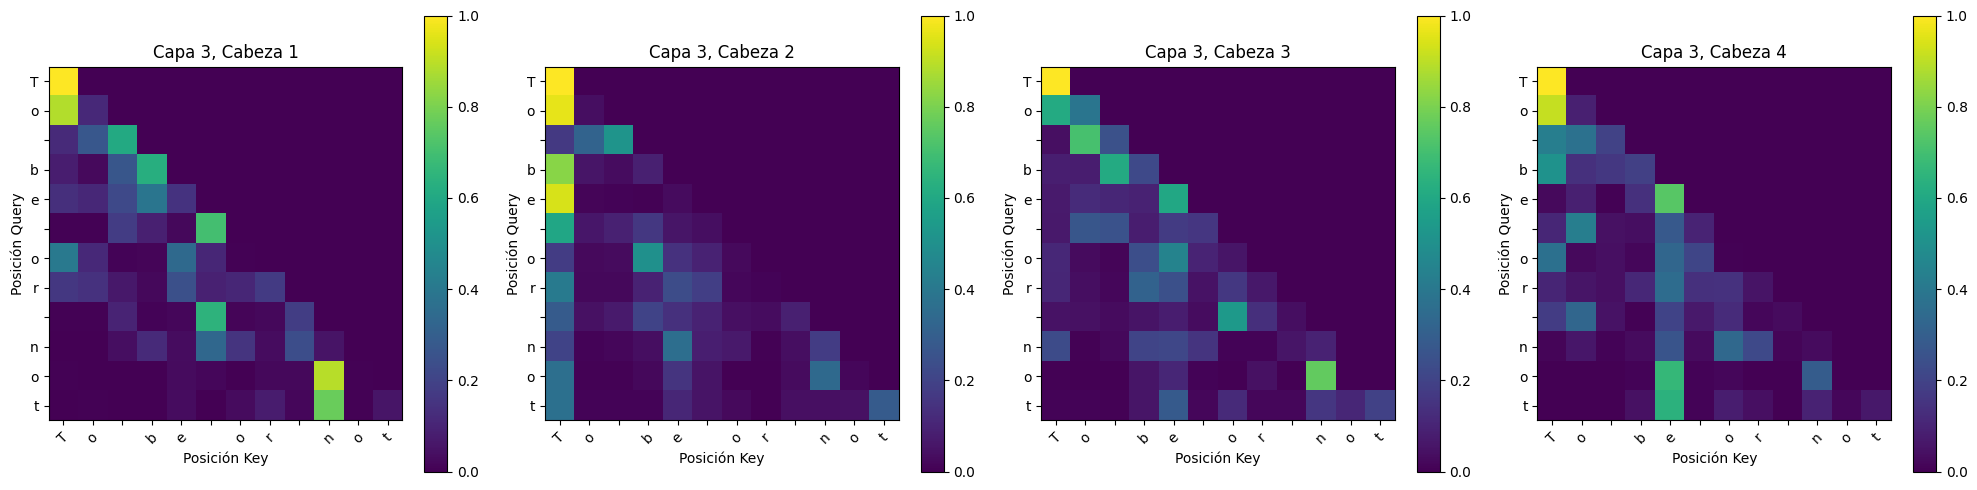

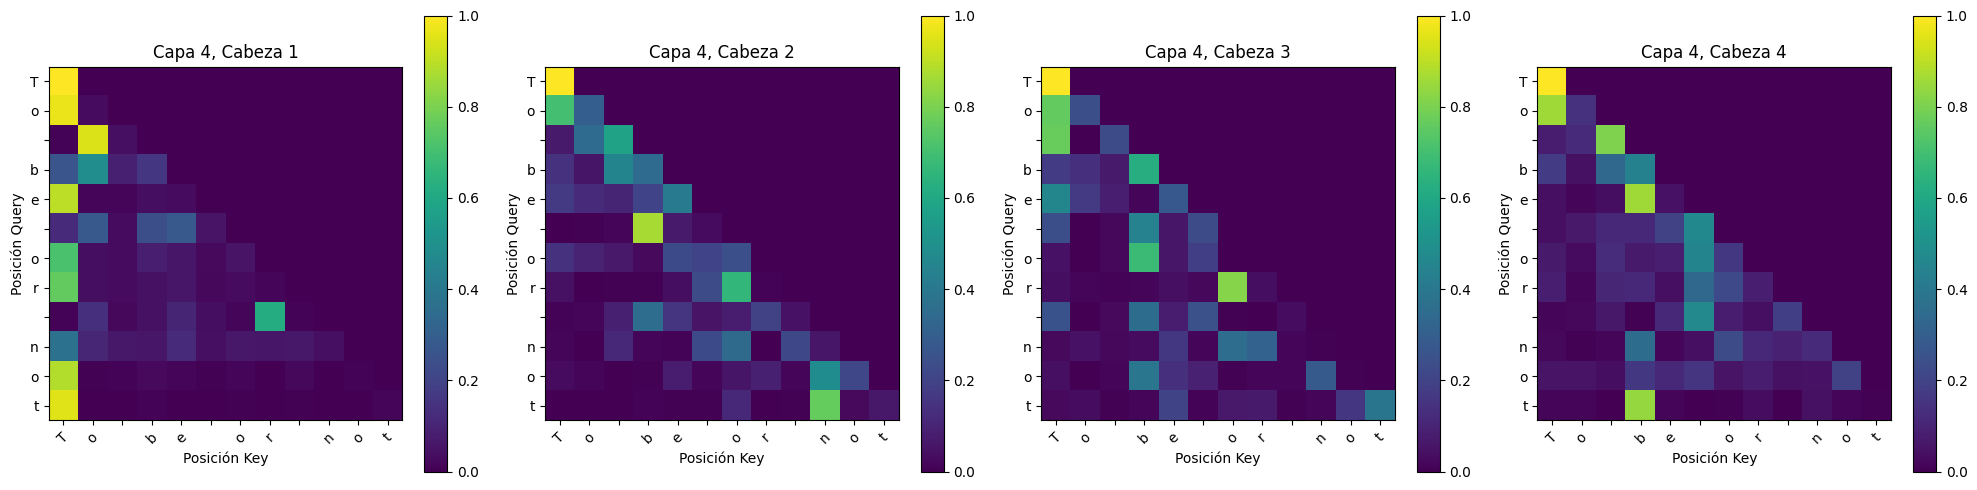

In [22]:
print("\n" + "="*60)
print("VISUALIZACIÓN DE ATENCIÓN")
print("="*60)

prompt = "To be or not"
print(f"\nVisualizando atención para: '{prompt}'")

try:
    visualize_attention(model_moe, prompt)
except Exception as e:
    print(f"Error en visualización: {e}")

## 20. Conclusiones

### Mixture of Experts (MoE)

1. **Arquitectura MoE**: Implementamos una capa MoE con routing top-k, donde cada token
   selecciona dinámicamente un subconjunto de expertos especializados.

2. **Balanceo de Carga**: La pérdida auxiliar incentiva distribución uniforme de tokens
   entre expertos, evitando el colapso donde un solo experto procesa todo.

3. **Eficiencia**: Aunque MoE tiene más parámetros totales, el costo computacional
   por token es similar al modelo base porque solo se activan K expertos.

### Estrategias de Decodificación

1. **Greedy**: Determinista, pero puede producir texto repetitivo.

2. **Temperature**: Controla la "creatividad":
   - T < 1: Distribución más concentrada (más determinista)
   - T > 1: Distribución más uniforme (más aleatorio)

3. **Top-K**: Limita el muestreo a los K tokens más probables, reduciendo
   generación de tokens muy improbables.

4. **Top-P (Nucleus)**: Más adaptativo que top-k, ajusta dinámicamente el
   número de tokens considerados según la distribución de probabilidad.

### Observaciones

- MoE permite escalar modelos con más parámetros sin aumentar linealmente el cómputo.
- La combinación de temperature + top-k/top-p produce texto más coherente y diverso.
- El routing sparse de MoE permite especialización de expertos en diferentes patrones.